# Business Problem
Customer churn is a major challenge in the telecommunications industry. When customers discontinue their service with a telecom provider, the company loses recurring revenue and incurs additional costs to acquire new customers.

Predicting which customers are likely to churn allows companies to implement proactive retention strategies, such as targeted promotions or improved customer support.

# Project Objective
The objective of this project is to develop a machine learning system capable of predicting whether a customer will churn based on their service usage patterns and account characteristics.

# Expected Outcome
The resulting model will enable the telecommunication company to:
- Identify customers at risk of leaving
- Prioritise retention efforts
- Reduce revenue loss due to churn

In [14]:
#Import python library and load the dataset
import pandas as pd

df = pd.read_csv('Data/bigml_59c28831336c6604c800002a.csv')
df.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


This code loads the telecom dataset using the **pandas library and displays the first five rows of the dataset.

The purpose of this step is to inspect the structure of the dataset, verify that the data loaded correctly, and obtain an initial understanding of the available variables.

### Output interpretation
The dataset contains several types of variables:
- **Customer Identifiers** (phone number)
- **Service Plans** (international plans, voicemail plan)
- **Usage statistics** (call minutes and calls)
- **Billing variables** (charges)
- **Customer service interactions**
- **Target variable** (churn)

The churn feature represents whether a customer discontinues the service.


In [15]:
#Inspect number of rows and columns in the dataset
df.shape

(3333, 21)

## Dataset Dimensions
Understanding the size of the dataset helps determine: 
- the scale of analysis
- potential computational requirements
- whether the dataset is large enough for machine learning modeling

The dataset contains: 
- **3333 observations/customers**
- **21 features**

This dataset size is sufficient for training and evaluating several machine learning models.

In [16]:
#Data types and structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

## Data Types and Structure
The method has given us a summary of the dataset. From the output we observe:
- **8 int variables**
- **8 floating-point variables**
- **4 categorical variables**
- **1 boolean target variable(churn)**

Most important is all columns contain 3333 non-null values. There are no missing values in the dataset. This simplifies the preprocessing stage since no imputation is required.

In [17]:
#check for target variable distribution
df['churn'].value_counts()

False    2850
True      483
Name: churn, dtype: int64

# Target Variable Distribution
Understanding the distribution of the target variable is important because imbalanced datasets can bias machine learning models.

The results show 
- **2850 customers did not churn**
- **483 customers churned**

This means approx 14.5% of customers left  the service. The dataset therefore exhibits class imbalance which is expected in churn prediction problems.

During model evaluation, we must therefore consider metrics beyond simple accuracy. We will consider classification metrics such as:
- precision
- recall
- F1-score

In [18]:
#identify irrelevant features
df.columns

Index(['state', 'account length', 'area code', 'phone number',
       'international plan', 'voice mail plan', 'number vmail messages',
       'total day minutes', 'total day calls', 'total day charge',
       'total eve minutes', 'total eve calls', 'total eve charge',
       'total night minutes', 'total night calls', 'total night charge',
       'total intl minutes', 'total intl calls', 'total intl charge',
       'customer service calls', 'churn'],
      dtype='object')

## Feature overview
Reviewing the available features allows us to understand what information is available and how it might contribute to predicting customer churn.

The dataset contains 21 variables describing different aspects of customer behavior and account characteristics. These variables can be grouped into several logical categories:

**Customer Identification**(These variables identify customers or their geographic region.)
- phone number
- state
- area code

**Account Information**(This indicates how long a customer has been with the telecom company.)
- account length

**Service Plans**(These variables describe whether a customer subscribes to optional telecom services.)
- international plan
- voice mail plan

**Voicemail Usage**(This variable records the number of voicemail messages associated with the customer.)
- number vmail messages

**Call Usage Metrics**()
These variables capture call activity across different periods of the day:

1. Day usage:
- total day minutes
- total day calls
- total day charge

2. Evening usage:
- total eve minutes
- total eve calls
- total eve charge

3. Night usage:
- total night minutes
- total night calls
- total night charge

4. International usage:
- total intl minutes
- total intl calls
- total intl charge

**Customer Support Interaction**(This variable measures how many times the customer contacted customer support.)
- customer service calls

**Frequent support calls may indicate dissatisfaction, making this variable potentially important for churn prediction.**

**Target Variable** (This boolean variable indicates whether the customer discontinued their telecom service.)
- churn





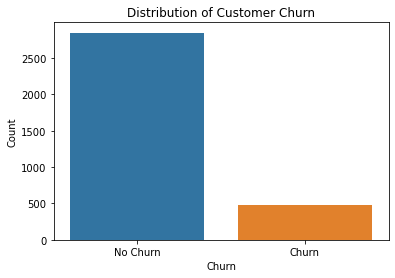

In [19]:
#EDA Visualizing distribution of the target variable
import matplotlib.pyplot as plt
import seaborn as sns   

sns.countplot(x='churn', data=df)
plt.title('Distribution of Customer Churn')
plt.xlabel('Churn')
plt.ylabel('Count')  
plt.xticks([0, 1], ['No Churn', 'Churn'])
plt.savefig("Presentation/target_variable_distribution.png", dpi=300, bbox_inches='tight')   
plt.show()

## Distributuion of Customer Churn
The resulting bar chart shows that the majority of the customers did not churn, while a smaller portion left the service.

This confirms that the dataset is imbalanced, with approximately 14.5% churn rate. Class imbalance is common in churn prediction problems and must be considered when selecting model evaluation metrics.

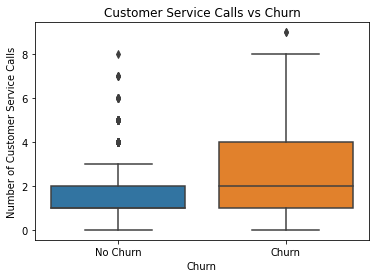

In [21]:
#EDA Visualising Customer Service Calls vs churn
sns.boxplot(x='churn', y='customer service calls', data=df)
plt.title('Customer Service Calls vs Churn')    
plt.xlabel('Churn')
plt.ylabel('Number of Customer Service Calls')  
plt.xticks([0, 1], ['No Churn', 'Churn'])
plt.savefig("Presentation/customer_service_calls_vs_churn.png", dpi=300, bbox_inches='tight')
plt.show()  

### Customer Service Calls vs Churn
The boxplot reveals a clear pattern between customer service interactions and churn.Customers who churned tend to have a higher median number of customer service calls compared to customers who did not churn. This suggests that customers who frequently contact customer support may be experiencing unresolved issues or dissatisfaction with the service.

The churned group shows a wider spread of values, indicating that some customers contacted customer service significantly more often before leaving.
This could indicate escalating frustration prior to churn.

Several outliers are visible, representing customers who contacted customer service an unusually high number of times.
These extreme cases may indicate severe dissatisfaction or unresolved service problems.
Such customers could represent high-risk churn cases

This visualisation helps us conclude **customer support interaction is an important predictor of churn** 

Customers who repeatedly contact service appear more likely to discontinue their telecom service. This insight highlights a potential early warning signal for churn.

Telecom companies could use the number of customer service calls as a trigger for proactive intervention strategies such as:
- **prioritizing customer support for frequent callers**
- **offering retention incentives**
- **escalating unresolved service issues**

**By identifying these customers early, companies can potentially reduce churn and improve customer satisfaction.**

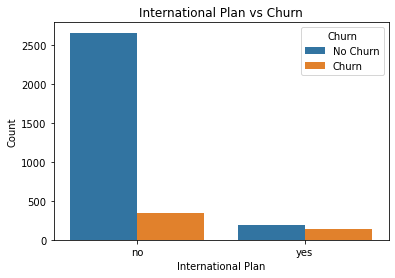

In [22]:
# investigate customers with international plan and their churn rate
sns.countplot(x='international plan', hue='churn', data=df)

plt.title('International Plan vs Churn')
plt.xlabel('International Plan')        
plt.ylabel('Count')
plt.legend(title='Churn', labels=['No Churn', 'Churn']) 
plt.savefig("Presentation/international_plan_vs_churn.png", dpi=300, bbox_inches='tight')
plt.show()

## Churn Rate of Customers with International Plan
Customers subscribed to the international plan show a significantly higher likelihood of churning compared to customers without the plan. This suggests the international plan segment may represent a high-risk customer group that requires targeted retention strategies.

The dataset show that most customers do not subscribe to the international plan. This indicates that international services represent a smaller segment of the customer base, but one that appears to have higher churn risk.

Several factors may explain this pattern:
- Higher service costs associated with international calls
- Competition from alternative communication platforms
- Customer dissatisfaction with international call rates
- Availability of cheaper international communication services

**Customers who frequently make international calls may therefore be more sensitive to pricing or service quality, increasing their likelihood of switching providers.**

The international plan variable appears to be a strong potential predictor of customer churn.

This feature should therefore be retained during model development and may significantly contribute to predicting churn in Machine Learning models.


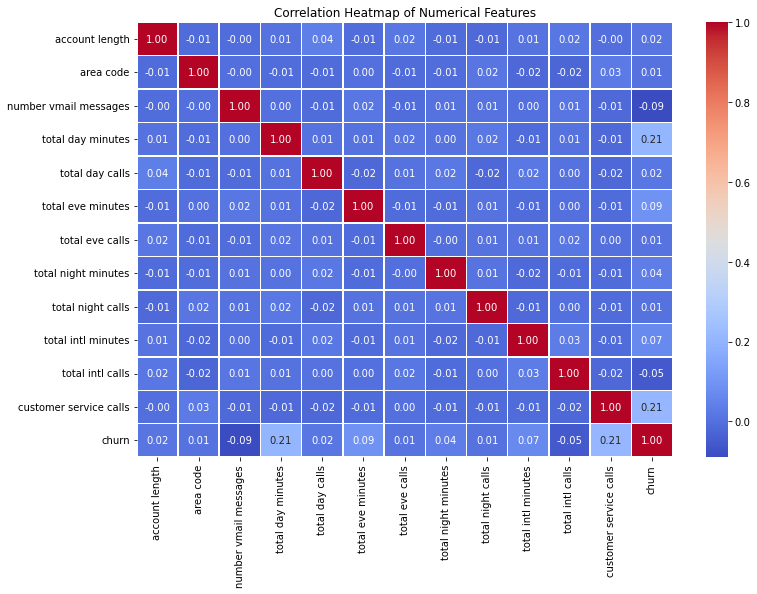

In [27]:
# Correlation Heatmap
corr_matrix = df.corr()

plt.figure(figsize=(12,8))

sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm', 
            fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.savefig("Presentation/correlation_heatmap.png", dpi=300, bbox_inches='tight')   
plt.show()

# Correlation Heatmap
A heatmap allows us to quickly observe relationships between variables by representing correlation values through color intesity. Correlation values range between -1 and +1 where:

- +1 shows a perfect positive relationship
- 0 shows no relationship
- 1 shows a perfect negative relationship

This visualisation helps identify:
- variables that may influence churn
- redundant variables
- possible multicollinearity issues

## 1. Most Features Have Weak Correlation With Each Other
The majority of variables exhibit correlation values close to 0, indicating that they are largely independent of one another.
This is beneficial for machine learning models because it suggests that the dataset does not suffer from widespread multicollinearity.
Low correlation between predictors helps models learn distinct patterns from each feature.

## 2. Moderate Correlation Between Some Usage Features
Some variables related to call activity show mild correlations. These relationships are expected because they describe similar customer behaviors, such as call frequency and call duration.
However, these correlations are not strong enough to warrant immediate removal of variables.

## 3. Limited Linear Relationship With Churn
The heatmap shows that most numerical variables have relatively weak linear correlations with the churn variable.
The strongest correlations appear to be around 0.21, which is still considered a relatively weak linear relationship.
This suggests that churn is likely influenced by multiple factors interacting together, rather than a single dominant numerical predictor.
This observation is common in real-world churn prediction problems.

The heatmap has provided an important clue, several pair of variables related to call minutes and charges appear extremely correlated. This observation encourages us to do a multicollinearity investigation to confirm that billing variables are derived directly from call duration variables, if so we will remove redudant charge variables from the dataset to simplify the modelling process.

In [23]:
#checking for multicollinearity in total day minutes and total day charge
df[['total day minutes', 'total day charge']].corr()

,total day minutes,total day charge
total day minutes,1.0,1.0
total day charge,1.0,1.0


In [24]:
#checking for multicollinearity in total eve minutes and total eve charge
df[['total eve minutes', 'total eve charge']].corr()

,total eve minutes,total eve charge
total eve minutes,1.0,1.0
total eve charge,1.0,1.0


In [25]:
#checking for multicollinearity in total night minutes and total night charge
df[['total night minutes', 'total night charge']].corr()

,total night minutes,total night charge
total night minutes,1.000000,0.999999
total night charge,0.999999,1.000000


 Multicollinearity is present in the total day minutes and total day charge, total eve minutes and total eve charge, and total night minutes and total night charge features. We will drop the charge features to avoid multicollinearity issues in our model. Because including both variables in a machine learning model would introduce redundant features.

 Multicollinearity can:
 - inflate feature importance estimates
 - reduce model interpretability
 - introduce unnecessary complexity

## Feature Selection Decision
To avoid redundancy in the model, we will retain the call duration variables and remove the corresponding charge variables.
This decision simplifies the dataset while preserving the underlying information.

The columns that will be removed are:
- total day charge
- total eve charge
- total night charge
- total intl charge

This step removes the billing variables that were found to be perfectly correlated with call duration variables.
Removing redundant variables helps:

- reduce dimensionality
- prevent multicollinearity
- improve model interpretability


In [26]:
#Removing Redundant Features
df = df.drop(columns=[
    'total day charge', 
    'total eve charge', 
    'total night charge',
    'total intl charge'
    ])

In [28]:
#Ranking Features by Correlation with Target Variable
#compute correlation of all numeric features with the target variable 'churn'
churn_corr = df.corr()['churn'].abs().sort_values(ascending=False)
churn_corr

churn                     1.000000
customer service calls    0.208750
total day minutes         0.205151
total eve minutes         0.092796
number vmail messages     0.089728
total intl minutes        0.068239
total intl calls          0.052844
total night minutes       0.035493
total day calls           0.018459
account length            0.016541
total eve calls           0.009233
area code                 0.006174
total night calls         0.006141
Name: churn, dtype: float64

## Ranking Features by Correlation With Churn
1. Customer Service Calls Is the Strongest Predictor
The variable customer service calls has the highest correlation with churn among the numerical variables.
This suggests that customers who frequently contact customer support are more likely to discontinue their telecom service.
This finding aligns with the earlier visualization, which indicated that customers who churned tended to make more customer service calls.

2. High Daytime Usage Is Associated With Churn
The second strongest correlation is observed for total day minutes.
This indicates that customers who make more daytime calls may have a slightly higher tendency to churn.
Possible explanations include:
- higher billing costs for heavy daytime users
- increased sensitivity to pricing or service quality
- heavy users seeking alternative service providers

3. Other Variables Show Weak Individual Relationships
Most other variables have correlations below 0.10, which indicates relatively weak linear relationships with churn.
However, weak individual correlations do not imply that these features are unimportant.
Machine learning models can capture nonlinear relationships and interactions between variables, which may still make these features valuable predictors.

Customer Churn is not influenced by a single factor. Churn behavior results from multiple interacting factors including:
- service quality
- usage patterns
- pricing sensitivity
- customer satisfaction

Therefore, even variables with weak individual correlations may contribute to predictive performance when combined in a machine learning model.
This is one of the reasons why advanced models in Machine Learning are capable of outperforming simple statistical methods.

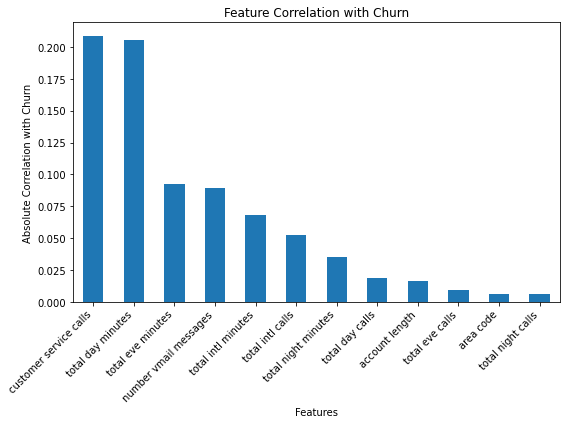

In [30]:
#Visualize the correlation of features with the target variable
churn_corr.drop('churn').plot(kind='bar', figsize=(8,6))

plt.title("Feature Correlation with Churn")
plt.xlabel("Features")
plt.ylabel("Absolute Correlation with Churn")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()  
plt.savefig("Presentation/feature_correlation_with_churn.png", dpi=300, bbox_inches='tight')
plt.show()